<a href="https://colab.research.google.com/github/Ranger3560/AI-Impact-Job-Layoff/blob/main/AI_Impact_Job_Layoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load CSV
df = pd.read_csv("/content/sample_data/ai-impact-jobs-layoff-risk-dataset.csv")

# View first rows
print(df.head())

# Dataset information
print(df.info())

# Summary statistics
print(df.describe())

   Age Education_Level  Years_of_Experience       Industry  \
0   59        Master's                    6        Finance   
1   44        Master's                   14  Manufacturing   
2   36      Bachelor's                    7         Retail   
3   27      Bachelor's                    6        Finance   
4   49     High School                   12        Finance   

                Job_Role Company_Size Job_Level  Routine_Task_Percentage  \
0             Accountant       Medium     Entry                       84   
1  Production Supervisor        Small     Entry                       30   
2          Store Manager       Medium    Senior                       12   
3                Auditor        Large     Entry                       90   
4                Auditor        Small     Entry                       49   

   Creativity_Requirement  Human_Interaction_Level AI_Adoption_Level  \
0                      21                       94            Medium   
1                      84 

In [3]:
print(df.isnull().sum())

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64


In [4]:
print("Average Age:", df["Age"].mean())

Average Age: 40.3615


In [5]:
print(df["Industry"].value_counts())

Industry
Telecom          2582
Healthcare       2561
Finance          2513
Logistics        2488
IT               2483
Retail           2467
Manufacturing    2457
Education        2449
Name: count, dtype: int64


In [6]:
print(df["Layoff_Risk"].value_counts())

Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64


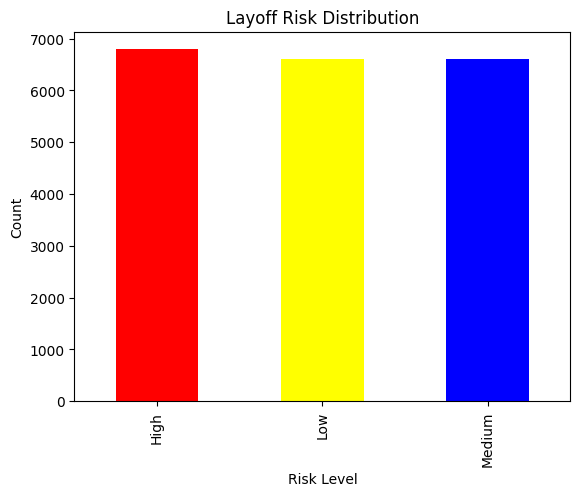

In [9]:
import matplotlib.pyplot as plt

df["Layoff_Risk"].value_counts().plot(
    kind="bar",
    color=["red", "yellow", "blue"]
)

plt.title("Layoff Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

# **AI Adoption By** **Industry**

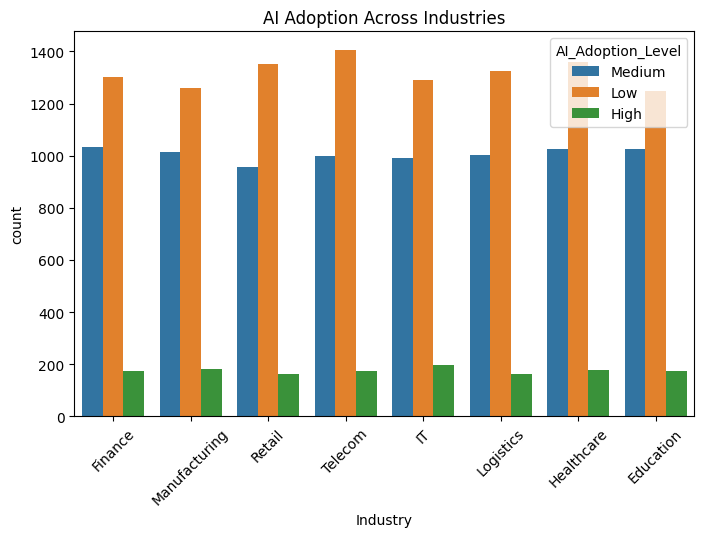

In [11]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Industry",
    hue="AI_Adoption_Level"
)

plt.xticks(rotation=45)
plt.title("AI Adoption Across Industries")
plt.show()

# **Correlation** **Analysis**

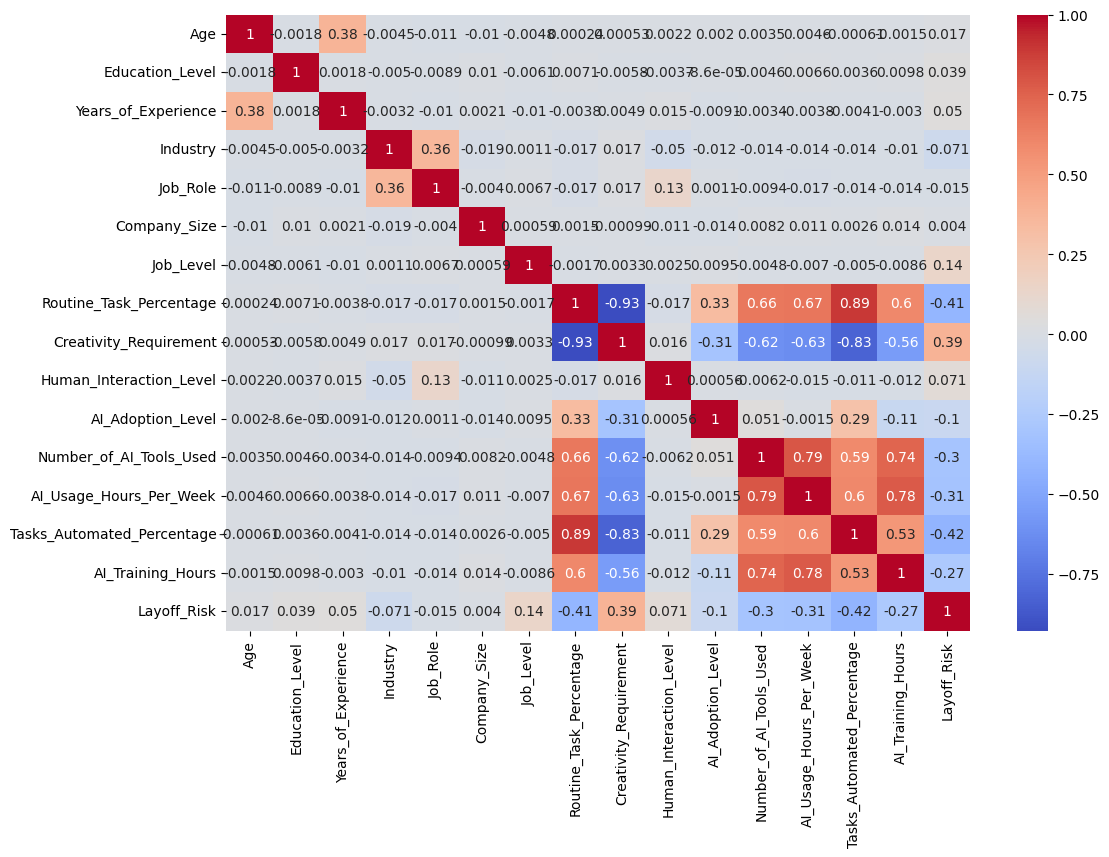

In [12]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

corr = df_encoded.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# **Predict Layoff Risk**

In [13]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

encoders = {}

for col in df_model.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

In [14]:
X = df_model.drop("Layoff_Risk", axis=1)
y = df_model["Layoff_Risk"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.888
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1375
           1       0.92      0.93      0.92      1296
           2       0.84      0.82      0.83      1329

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



# **Feature Importance**

                       Feature  Importance
7      Routine_Task_Percentage    0.172152
13  Tasks_Automated_Percentage    0.153957
8       Creativity_Requirement    0.143526
6                    Job_Level    0.094777
3                     Industry    0.065383
9      Human_Interaction_Level    0.062921
12     AI_Usage_Hours_Per_Week    0.053284
14           AI_Training_Hours    0.044802
2          Years_of_Experience    0.044554
1              Education_Level    0.039796
4                     Job_Role    0.036028
0                          Age    0.035198
11     Number_of_AI_Tools_Used    0.031407
5                 Company_Size    0.011458
10           AI_Adoption_Level    0.010759


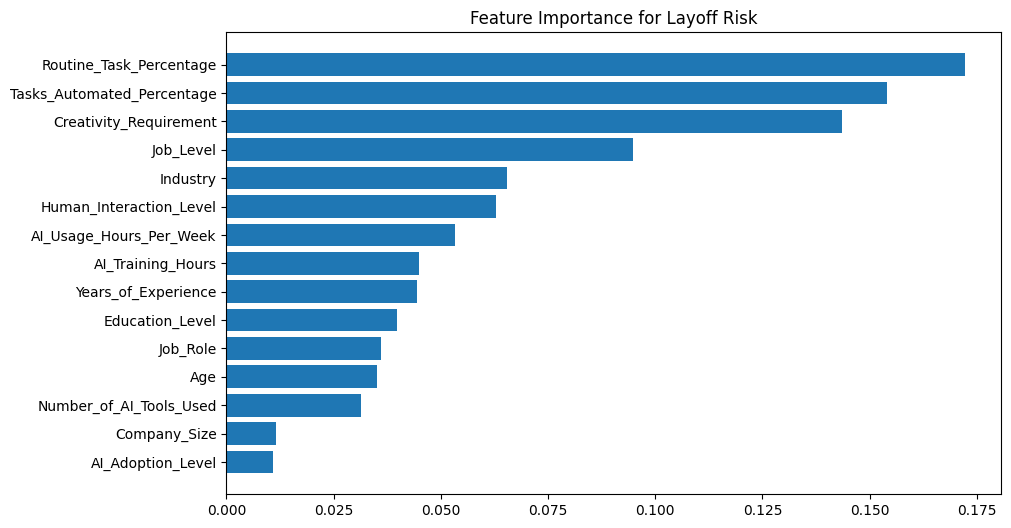

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance for Layoff Risk")
plt.show()

# **Predict a New Employee**

In [20]:
new_employee = [[
    35,      # Age
    1,       # Education (encoded)
    8,       # Years_of_Experience
    2,       # Industry
    4,       # Job_Role
    1,       # Company_Size
    0,       # Job_Level
    70,      # Routine_Tasks
    30,      # Creativity
    60,      # Human_Interaction
    2,       # AI_Adoption
    4,       # Number_of_AI_Tools
    8,       # AI_Usage_Hours
    55,      # Tasks_Automated
    20       # AI_Training
]]

prediction = model.predict(new_employee)

print("Predicted Layoff Risk:", prediction)

Predicted Layoff Risk: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
